# Hertfordshire-Secondary-School-Performance-Analysis

This notebook builds a four-year KS4 analysis panel for Hertfordshire schools using data published by the government (https://www.gov.uk/school-performance-tables).

Scope:
- Academic years: `2021-2022`, `2022-2023`, `2023-2024`, `2024-2025`
- Outcomes: Progress 8, Attainment 8, and English/maths grade 5+ measures
- Context: deprivation, attendance, SEND, school type, admissions policy, roll size, and gender

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.2f}".format)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
YEARS = ["2021-2022", "2022-2023", "2023-2024", "2024-2025"]


## Raw File Exploration

Before defining the analysis columns and filters, inspect the raw yearly files to see available columns, row counts, valid school rows, and census `SCHOOLTYPE` groups.

In [18]:
RAW_FILES = {
    "ks4": "919_ks4final.csv",
    "census": "919_census.csv",
    "absence": "919_abs.csv",
}
CANDIDATE_ANALYSIS_COLUMNS = [
    "P8MEA", "P8MEAENG", "P8MEAMAT", "P8MEAEBAC", "P8MEAOPEN",
    "ATT8SCR", "ATT8SCRENG", "ATT8SCRMAT", "ATT8SCREBAC", "ATT8SCROPEN",
    "PTL2BASICS_95", "PNUMFSMEVER", "PERCTOT", "PPERSABS10",
    "PSEN_ALL4", "SCHOOLTYPE", "ADMPOL", "NOR", "NORG", "NORB",
    "PNORG", "PNORB", "EGENDER",
]

raw_file_rows = []
raw_column_rows = []
raw_schooltype_rows = []

for year in YEARS:
    year_dir = DATA_DIR / year
    for source_name in RAW_FILES:
        file_name = RAW_FILES[source_name]
        path = year_dir / file_name
        if not path.exists():
            raw_file_rows.append({"academic_year": year, "file": file_name, "exists": False, "rows": 0, "columns": 0, "valid_urn_rows": pd.NA})
            continue

        data = pd.read_csv(path, dtype="string", low_memory=False)
        urn = pd.to_numeric(data["URN"], errors="coerce") if "URN" in data.columns else pd.Series(pd.NA, index=data.index)
        raw_file_rows.append(
            {
                "academic_year": year,
                "file": file_name,
                "exists": True,
                "rows": len(data),
                "columns": len(data.columns),
                "valid_urn_rows": int(urn.notna().sum()),
            }
        )

        for column in CANDIDATE_ANALYSIS_COLUMNS:
            if column in data.columns:
                raw_column_rows.append({"academic_year": year, "file": file_name, "column": column})

    census_path = year_dir / RAW_FILES["census"]
    if census_path.exists():
        census = pd.read_csv(census_path, dtype="string", low_memory=False)
        census["URN_NUM"] = pd.to_numeric(census["URN"], errors="coerce")
        census = census[census["URN_NUM"].notna()].drop_duplicates(subset="URN_NUM")
        for schooltype, count in census["SCHOOLTYPE"].fillna("<missing>").value_counts(dropna=False).items():
            raw_schooltype_rows.append({"academic_year": year, "SCHOOLTYPE": schooltype, "census_rows": int(count)})

raw_file_summary = pd.DataFrame(raw_file_rows)
raw_column_presence = (
    pd.DataFrame(raw_column_rows)
    .assign(present=True)
    .pivot_table(index=["column", "file"], columns="academic_year", values="present", aggfunc="any", fill_value=False)
    .reset_index()
)
raw_schooltype_counts = pd.DataFrame(raw_schooltype_rows).sort_values(["academic_year", "census_rows"], ascending=[True, False])
raw_schooltype_group_counts = raw_schooltype_counts.groupby("academic_year").size().rename("census_schooltype_groups")

display(raw_file_summary)
display(raw_column_presence)
display(raw_schooltype_group_counts)
display(raw_schooltype_counts)


,academic_year,file,exists,rows,columns,valid_urn_rows
0,2021-2022,919_ks4final.csv,True,132,514,129
1,2021-2022,919_census.csv,True,591,23,585
2,2021-2022,919_abs.csv,True,517,5,511
3,2022-2023,919_ks4final.csv,True,133,515,130
4,2022-2023,919_census.csv,True,591,23,585
5,2022-2023,919_abs.csv,True,517,5,511
6,2023-2024,919_ks4final.csv,True,133,429,130
7,2023-2024,919_census.csv,True,594,23,588
8,2023-2024,919_abs.csv,True,518,5,512
9,2024-2025,919_ks4final.csv,True,132,497,129


academic_year,column,file,2021-2022,2022-2023,2023-2024,2024-2025
0,ADMPOL,919_ks4final.csv,True,True,True,True
1,ATT8SCR,919_ks4final.csv,True,True,True,True
2,ATT8SCREBAC,919_ks4final.csv,True,True,True,True
3,ATT8SCRENG,919_ks4final.csv,True,True,True,True
4,ATT8SCRMAT,919_ks4final.csv,True,True,True,True
5,ATT8SCROPEN,919_ks4final.csv,True,True,True,True
6,EGENDER,919_ks4final.csv,True,True,True,True
7,NOR,919_census.csv,True,True,True,True
8,NORB,919_census.csv,True,True,True,True
9,NORG,919_census.csv,True,True,True,True


academic_year
2021-2022    7
2022-2023    7
2023-2024    7
2024-2025    7
Name: census_schooltype_groups, dtype: int64

,academic_year,SCHOOLTYPE,census_rows
0,2021-2022,State-funded primary,403
1,2021-2022,State-funded secondary,82
2,2021-2022,Independent school,52
3,2021-2022,State-funded special school,25
4,2021-2022,State-funded nursery,14
5,2021-2022,Pupil referral unit,8
6,2021-2022,Non-maintained special school,1
7,2022-2023,State-funded primary,402
8,2022-2023,State-funded secondary,83
9,2022-2023,Independent school,52


## Analysis Definitions

Based on the raw file exploration, define the final school-type filter, selected columns, and cleaning codes used by the loader.

In [19]:
ALLOWED_SCHOOLTYPES = ["State-funded secondary"]
EXPECTED_KS4_ROWS = {}

OUTCOME_COLUMNS = [
    "P8MEA",
    "P8MEAENG",
    "P8MEAMAT",
    "P8MEAEBAC",
    "P8MEAOPEN",
    "ATT8SCR",
    "ATT8SCRENG",
    "ATT8SCRMAT",
    "ATT8SCREBAC",
    "ATT8SCROPEN",
    "PTL2BASICS_95",
]

CONTEXT_COLUMNS = [
    "PNUMFSMEVER",
    "PERCTOT",
    "PPERSABS10",
    "PSEN_ALL4",
    "SCHOOLTYPE",
    "ADMPOL",
    "NOR",
    "NORG",
    "NORB",
    "PNORG",
    "PNORB",
    "EGENDER",
]

IDENTIFIER_COLUMNS = ["academic_year", "URN", "SCHNAME"]
ANALYSIS_COLUMNS = IDENTIFIER_COLUMNS + OUTCOME_COLUMNS + CONTEXT_COLUMNS
NUMERIC_COLUMNS = OUTCOME_COLUMNS + ["PNUMFSMEVER", "PERCTOT", "PPERSABS10", "PSEN_ALL4", "NOR", "NORG", "NORB", "PNORG", "PNORB"]

MISSING_CODES = {
    "",
    "-",
    "NA",
    "N/A",
    "NAN",
    "NE",
    "NEW",
    "NP",
    "SUPP",
    "LOWCOV",
    "SP",
    "X",
}


In [20]:
def clean_numeric(series: pd.Series) -> pd.Series:
    """Convert school performance strings, percentages, and suppression codes to numeric values."""
    text = series.astype("string").str.strip()
    text = text.str.replace(",", "", regex=False).str.replace("%", "", regex=False)
    text = text.mask(text.str.upper().isin(MISSING_CODES))
    return pd.to_numeric(text, errors="coerce")


def normalise_urn(series: pd.Series) -> pd.Series:
    """Normalise URNs that sometimes arrive as strings like '117600.0'."""
    return pd.to_numeric(series, errors="coerce").astype("Int64")


def read_selected_csv(path: Path, columns: list[str]) -> pd.DataFrame:
    """Read only requested columns and add missing requested columns as NA."""
    header = pd.read_csv(path, nrows=0).columns.tolist()
    present = [column for column in columns if column in header]
    data = pd.read_csv(path, usecols=present, dtype="string", low_memory=False)
    for column in columns:
        if column not in data.columns:
            data[column] = pd.NA
    return data[columns]


def load_year(year: str) -> pd.DataFrame:
    year_dir = DATA_DIR / year
    ks4_path = year_dir / RAW_FILES["ks4"]
    census_path = year_dir / RAW_FILES["census"]
    absence_path = year_dir / RAW_FILES["absence"]

    ks4_columns = ["URN", "SCHNAME", "EGENDER", "ADMPOL", "PSEN_ALL4"] + OUTCOME_COLUMNS
    census_columns = ["URN", "SCHOOLTYPE", "NOR", "NORG", "NORB", "PNORG", "PNORB", "PNUMFSMEVER"]
    absence_columns = ["URN", "PERCTOT", "PPERSABS10"]

    ks4 = read_selected_csv(ks4_path, ks4_columns)
    ks4["academic_year"] = year
    ks4["URN"] = normalise_urn(ks4["URN"])
    ks4 = ks4[ks4["URN"].notna()].copy()
    census = read_selected_csv(census_path, census_columns)
    census["URN"] = normalise_urn(census["URN"])
    census = census[census["URN"].notna()].drop_duplicates(subset="URN")

    panel = ks4.merge(census, on="URN", how="left", validate="many_to_one")
    # Keep only the school types selected for this analysis before building the panel.
    panel = panel[panel["SCHOOLTYPE"].isin(ALLOWED_SCHOOLTYPES)].copy()

    if absence_path.exists():
        absence = read_selected_csv(absence_path, absence_columns)
        absence["URN"] = normalise_urn(absence["URN"])
        absence = absence[absence["URN"].notna()].drop_duplicates(subset="URN")
        panel = panel.merge(absence, on="URN", how="left", validate="many_to_one")
    else:
        panel["PERCTOT"] = pd.NA
        panel["PPERSABS10"] = pd.NA

    for column in NUMERIC_COLUMNS:
        panel[column] = clean_numeric(panel[column])

    return panel[ANALYSIS_COLUMNS]


def build_panel(years: list[str] = YEARS) -> pd.DataFrame:
    return pd.concat([load_year(year) for year in years], ignore_index=True)

## Preliminary Source Audit

This section derives the row-count checks, inspects the census `SCHOOLTYPE` groups, and identifies which groups are retained for the analysis panel.

In [21]:
audit_rows = []
schooltype_rows = []
column_availability_rows = []

source_columns = {
    "ks4": ["URN", "SCHNAME", "EGENDER", "ADMPOL", "PSEN_ALL4"] + OUTCOME_COLUMNS,
    "census": ["URN", "SCHOOLTYPE", "NOR", "NORG", "NORB", "PNORG", "PNORB", "PNUMFSMEVER"],
    "absence": ["URN", "PERCTOT", "PPERSABS10"],
}

for year in YEARS:
    year_dir = DATA_DIR / year
    source_paths = {source_name: year_dir / file_name for source_name, file_name in RAW_FILES.items()}
    ks4_path = source_paths["ks4"]
    census_path = source_paths["census"]
    absence_path = source_paths["absence"]

    ks4_raw = pd.read_csv(ks4_path, dtype="string", low_memory=False)
    ks4_urn = normalise_urn(ks4_raw["URN"])
    valid_ks4 = ks4_raw.assign(URN_NUM=ks4_urn).loc[ks4_urn.notna()].copy()

    audit_rows.append(
        {
            "academic_year": year,
            "raw_ks4_rows": len(ks4_raw),
            "valid_urn_rows": int(ks4_urn.notna().sum()),
            "invalid_urn_rows": int(ks4_urn.isna().sum()),
            "unique_school_urns": int(ks4_urn.dropna().nunique()),
        }
    )

    census_raw = pd.read_csv(census_path, dtype="string", low_memory=False)
    census = census_raw.assign(URN_NUM=normalise_urn(census_raw["URN"]))
    census = census[census["URN_NUM"].notna()].drop_duplicates(subset="URN_NUM")
    schooltype_join = valid_ks4[["URN_NUM"]].merge(
        census[["URN_NUM", "SCHOOLTYPE"]], on="URN_NUM", how="left", validate="many_to_one"
    )
    audit_rows[-1]["retained_schooltype_rows"] = int(schooltype_join["SCHOOLTYPE"].isin(ALLOWED_SCHOOLTYPES).sum())
    schooltype_counts = schooltype_join["SCHOOLTYPE"].fillna("<missing>").value_counts(dropna=False)
    for schooltype, count in schooltype_counts.items():
        schooltype_rows.append(
            {
                "academic_year": year,
                "SCHOOLTYPE": schooltype,
                "schools": int(count),
                "kept_in_analysis": schooltype in ALLOWED_SCHOOLTYPES,
                "share_pct": round(count / len(valid_ks4) * 100, 1),
            }
        )

    for source_name, expected_columns in source_columns.items():
        path = source_paths[source_name]
        if path.exists():
            columns = set(pd.read_csv(path, nrows=0).columns)
            missing = [column for column in expected_columns if column not in columns]
            present = len(expected_columns) - len(missing)
        else:
            missing = expected_columns
            present = 0
        column_availability_rows.append(
            {
                "academic_year": year,
                "source": source_name,
                "expected_columns": len(expected_columns),
                "present_columns": present,
                "missing_columns": ", ".join(missing) if missing else "",
            }
        )

source_audit = pd.DataFrame(audit_rows)
schooltype_counts = pd.DataFrame(schooltype_rows).sort_values(["academic_year", "schools"], ascending=[True, False])
schooltype_group_counts = schooltype_counts.groupby("academic_year").size().rename("all_discovered_schooltype_groups")
retained_schooltype_counts = schooltype_counts[schooltype_counts["kept_in_analysis"]].copy()
retained_schooltype_group_counts = retained_schooltype_counts.groupby("academic_year").size().rename("retained_schooltype_groups")
column_availability = pd.DataFrame(column_availability_rows)
EXPECTED_KS4_ROWS = source_audit.set_index("academic_year")["retained_schooltype_rows"].to_dict()

display(source_audit)
display(column_availability)
display(schooltype_group_counts)
display(retained_schooltype_group_counts)
display(retained_schooltype_counts)

,academic_year,raw_ks4_rows,valid_urn_rows,invalid_urn_rows,unique_school_urns,retained_schooltype_rows
0,2021-2022,132,129,3,129,80
1,2022-2023,133,130,3,130,81
2,2023-2024,133,130,3,130,79
3,2024-2025,132,129,3,129,80


,academic_year,source,expected_columns,present_columns,missing_columns
0,2021-2022,ks4,16,16,
1,2021-2022,census,8,8,
2,2021-2022,absence,3,3,
3,2022-2023,ks4,16,16,
4,2022-2023,census,8,8,
5,2022-2023,absence,3,3,
6,2023-2024,ks4,16,16,
7,2023-2024,census,8,8,
8,2023-2024,absence,3,3,
9,2024-2025,ks4,16,16,


academic_year
2021-2022    5
2022-2023    5
2023-2024    5
2024-2025    4
Name: all_discovered_schooltype_groups, dtype: int64

academic_year
2021-2022    1
2022-2023    1
2023-2024    1
2024-2025    1
Name: retained_schooltype_groups, dtype: int64

,academic_year,SCHOOLTYPE,schools,kept_in_analysis,share_pct
0,2021-2022,State-funded secondary,80,True,62.00
5,2022-2023,State-funded secondary,81,True,62.30
10,2023-2024,State-funded secondary,79,True,60.80
15,2024-2025,State-funded secondary,80,True,62.00


In [22]:
panel = build_panel()

display(panel.head())
display(panel.tail())
print(f"Rows: {len(panel):,}")
print(f"Columns: {len(panel.columns):,}")

,academic_year,URN,SCHNAME,P8MEA,P8MEAENG,P8MEAMAT,P8MEAEBAC,P8MEAOPEN,ATT8SCR,ATT8SCRENG,ATT8SCRMAT,ATT8SCREBAC,ATT8SCROPEN,PTL2BASICS_95,PNUMFSMEVER,PERCTOT,PPERSABS10,PSEN_ALL4,SCHOOLTYPE,ADMPOL,NOR,NORG,NORB,PNORG,PNORB,EGENDER
0,2021-2022,145430,The Adeyfield Academy,-0.67,-0.56,-0.46,-1.32,-0.29,34.90,8.00,6.90,8.00,11.90,21.00,40.34,11.10,36.60,25.00,State-funded secondary,NSE,642,305,337,47.51,52.49,MIXED
1,2021-2022,117578,Ashlyns School,0.16,0.20,0.05,0.09,0.24,54.50,11.70,10.40,15.70,16.70,61.00,12.30,8.70,25.10,17.00,State-funded secondary,NSE,1484,730,754,49.19,50.81,MIXED
2,2021-2022,117552,The Astley Cooper School,-0.64,-0.58,-0.59,-0.74,-0.66,38.90,8.60,7.50,10.80,11.90,34.00,34.37,9.10,30.70,18.00,State-funded secondary,NSE,857,429,428,50.06,49.94,MIXED
3,2021-2022,144623,Barclay Academy,0.41,0.43,0.70,0.41,0.21,52.50,11.30,10.70,15.20,15.40,67.00,27.66,9.80,32.20,15.00,State-funded secondary,NSE,718,342,376,47.63,52.37,MIXED
4,2021-2022,117518,Barnwell School,-0.58,-0.45,-0.57,-0.69,-0.57,43.20,9.60,8.30,12.20,13.10,34.00,27.64,8.60,23.10,21.00,State-funded secondary,NSE,1151,565,586,49.09,50.91,MIXED


,academic_year,URN,SCHNAME,P8MEA,P8MEAENG,P8MEAMAT,P8MEAEBAC,P8MEAOPEN,ATT8SCR,ATT8SCRENG,ATT8SCRMAT,ATT8SCREBAC,ATT8SCROPEN,PTL2BASICS_95,PNUMFSMEVER,PERCTOT,PPERSABS10,PSEN_ALL4,SCHOOLTYPE,ADMPOL,NOR,NORG,NORB,PNORG,PNORB,EGENDER
315,2024-2025,137038,Verulam School,<NA>,<NA>,<NA>,<NA>,<NA>,52.50,11.20,10.50,15.60,15.10,55.30,15.12,<NA>,<NA>,14.50,State-funded secondary,NSE,984,24,960,2.44,97.56,BOYS
316,2024-2025,136276,Watford Grammar School for Boys,<NA>,<NA>,<NA>,<NA>,<NA>,68.90,13.90,14.30,21.30,19.40,83.30,7.31,<NA>,<NA>,10.40,State-funded secondary,NSE,1610,0,1610,0.00,100.00,BOYS
317,2024-2025,136289,Watford Grammar School for Girls,<NA>,<NA>,<NA>,<NA>,<NA>,68.20,14.20,13.30,20.40,20.30,83.20,7.18,<NA>,<NA>,7.70,State-funded secondary,NSE,1429,1429,0,100.00,0.00,GIRLS
318,2024-2025,140049,Westfield Academy,<NA>,<NA>,<NA>,<NA>,<NA>,41.40,9.10,7.80,12.40,12.10,38.50,27.84,<NA>,<NA>,14.40,State-funded secondary,NSE,1335,639,696,47.87,52.13,MIXED
319,2024-2025,136922,Yavneh College,<NA>,<NA>,<NA>,<NA>,<NA>,61.60,13.00,12.00,18.40,18.20,75.00,6.47,<NA>,<NA>,23.70,State-funded secondary,NSE,1042,484,558,46.45,53.55,MIXED


Rows: 320
Columns: 26


## Data Checks

These checks confirm that the notebook is using the intended school universe and source mapping.

In [23]:
assert EXPECTED_KS4_ROWS, "Run the Preliminary Source Audit section before the data checks."
actual_counts = panel.groupby("academic_year").size().to_dict()
assert actual_counts == EXPECTED_KS4_ROWS, actual_counts

for column in ["SCHOOLTYPE", "NOR", "NORG", "NORB", "PNORG", "PNORB", "PNUMFSMEVER"]:
    assert panel.groupby("academic_year")[column].apply(lambda values: values.notna().any()).all(), column

assert set(panel["SCHOOLTYPE"].dropna().unique()).issubset(set(ALLOWED_SCHOOLTYPES))

assert "EGENDER" in panel.columns
assert "GENDER" not in panel.columns

assert panel.loc[panel["academic_year"] == "2024-2025", ["PERCTOT", "PPERSABS10"]].isna().all().all()
assert panel.loc[panel["academic_year"] == "2024-2025", ["P8MEA", "P8MEAENG", "P8MEAMAT", "P8MEAEBAC", "P8MEAOPEN"]].isna().all().all()

print("All checks passed.")
display(pd.Series(actual_counts, name="ks4_rows"))

All checks passed.


2021-2022    80
2022-2023    81
2023-2024    79
2024-2025    80
Name: ks4_rows, dtype: int64

## Coverage and Missingness

In [24]:
non_null_counts = panel.groupby("academic_year")[OUTCOME_COLUMNS + CONTEXT_COLUMNS].count().T
missing_rates = panel.groupby("academic_year")[OUTCOME_COLUMNS + CONTEXT_COLUMNS].apply(lambda frame: frame.isna().mean() * 100).T

display(non_null_counts)
display(missing_rates.round(1))

academic_year,2021-2022,2022-2023,2023-2024,2024-2025
P8MEA,79,79,77,0
P8MEAENG,79,79,77,0
P8MEAMAT,79,79,77,0
P8MEAEBAC,79,79,77,0
P8MEAOPEN,79,79,77,0
ATT8SCR,79,79,77,79
ATT8SCRENG,79,79,77,79
ATT8SCRMAT,79,79,77,79
ATT8SCREBAC,79,79,77,79
ATT8SCROPEN,79,79,77,79


academic_year,2021-2022,2022-2023,2023-2024,2024-2025
P8MEA,1.20,2.50,2.50,100.00
P8MEAENG,1.20,2.50,2.50,100.00
P8MEAMAT,1.20,2.50,2.50,100.00
P8MEAEBAC,1.20,2.50,2.50,100.00
P8MEAOPEN,1.20,2.50,2.50,100.00
ATT8SCR,1.20,2.50,2.50,1.20
ATT8SCRENG,1.20,2.50,2.50,1.20
ATT8SCRMAT,1.20,2.50,2.50,1.20
ATT8SCREBAC,1.20,2.50,2.50,1.20
ATT8SCROPEN,1.20,2.50,2.50,1.20


## Outcome Trends

,P8MEA,P8MEAENG,P8MEAMAT,P8MEAEBAC,P8MEAOPEN
academic_year,,,,,
2021-2022,0.15,0.11,0.11,0.16,0.16
2022-2023,0.17,0.18,0.15,0.22,0.11
2023-2024,0.21,0.17,0.19,0.23,0.20
2024-2025,<NA>,<NA>,<NA>,<NA>,<NA>


,ATT8SCR,ATT8SCRENG,ATT8SCRMAT,ATT8SCREBAC,ATT8SCROPEN,PTL2BASICS_95
academic_year,,,,,,
2021-2022,52.93,11.14,10.24,15.52,16.03,56.25
2022-2023,50.67,10.75,9.97,14.90,15.05,53.06
2023-2024,50.62,10.69,10.04,14.96,14.94,53.75
2024-2025,50.75,10.68,10.04,14.98,15.04,52.81


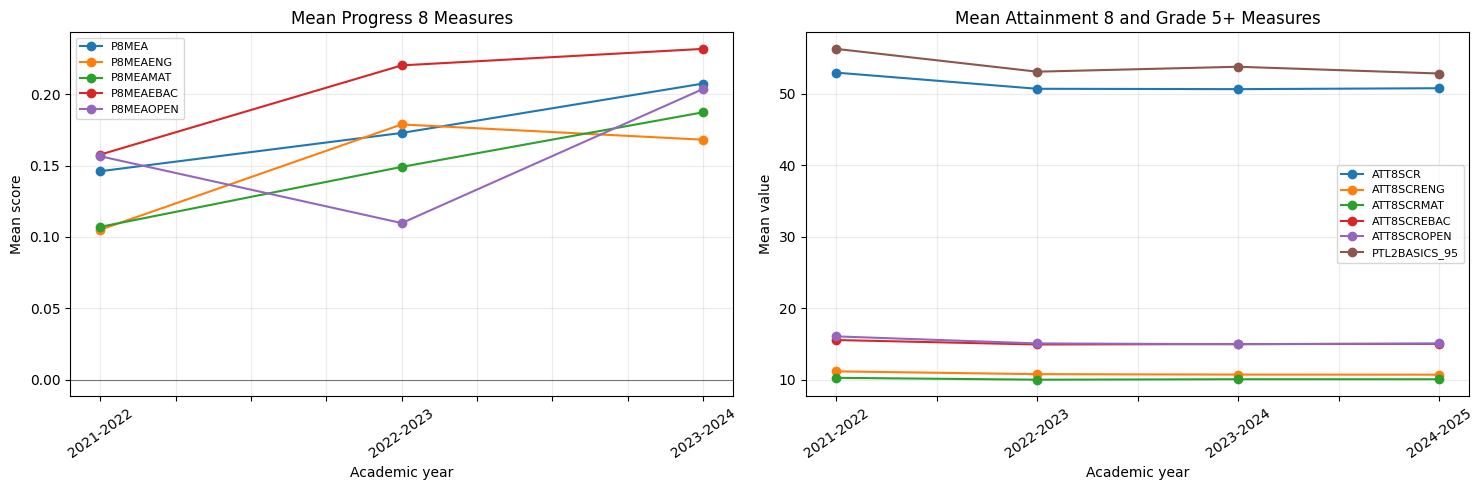

In [25]:
progress8_columns = ["P8MEA", "P8MEAENG", "P8MEAMAT", "P8MEAEBAC", "P8MEAOPEN"]
attainment8_columns = ["ATT8SCR", "ATT8SCRENG", "ATT8SCRMAT", "ATT8SCREBAC", "ATT8SCROPEN"]

progress8_trends = panel.groupby("academic_year")[progress8_columns].mean()
attainment_trends = panel.groupby("academic_year")[attainment8_columns + ["PTL2BASICS_95"]].mean()

display(progress8_trends.round(2))
display(attainment_trends.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
progress8_trends.plot(marker="o", ax=axes[0])
axes[0].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[0].set_title("Mean Progress 8 Measures")
axes[0].set_xlabel("Academic year")
axes[0].set_ylabel("Mean score")
axes[0].tick_params(axis="x", rotation=35)

attainment_trends.plot(marker="o", ax=axes[1])
axes[1].set_title("Mean Attainment 8 and Grade 5+ Measures")
axes[1].set_xlabel("Academic year")
axes[1].set_ylabel("Mean value")
axes[1].tick_params(axis="x", rotation=35)

for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)

plt.tight_layout()

* Average Progress 8 scores across Hertfordshire secondary schools were consistently above the national benchmark between 2021/22 and 2023/24, suggesting pupils made modestly stronger progress than comparable pupils nationally
* Above-average Progress 8 outcomes may partly reflect local demographic and admissions dynamics, including selective and partially selective intake patterns that are not fully captured by published admissions-policy classifications
* Published admissions-policy classifications did not consistently identify all academically selective or partially selective schools. Additional contextual interpretation was therefore required when analysing selectivity-related patterns

## Context Relationships

The following charts use only `State-funded secondary` schools. They are descriptive associations and do not estimate causal effects.

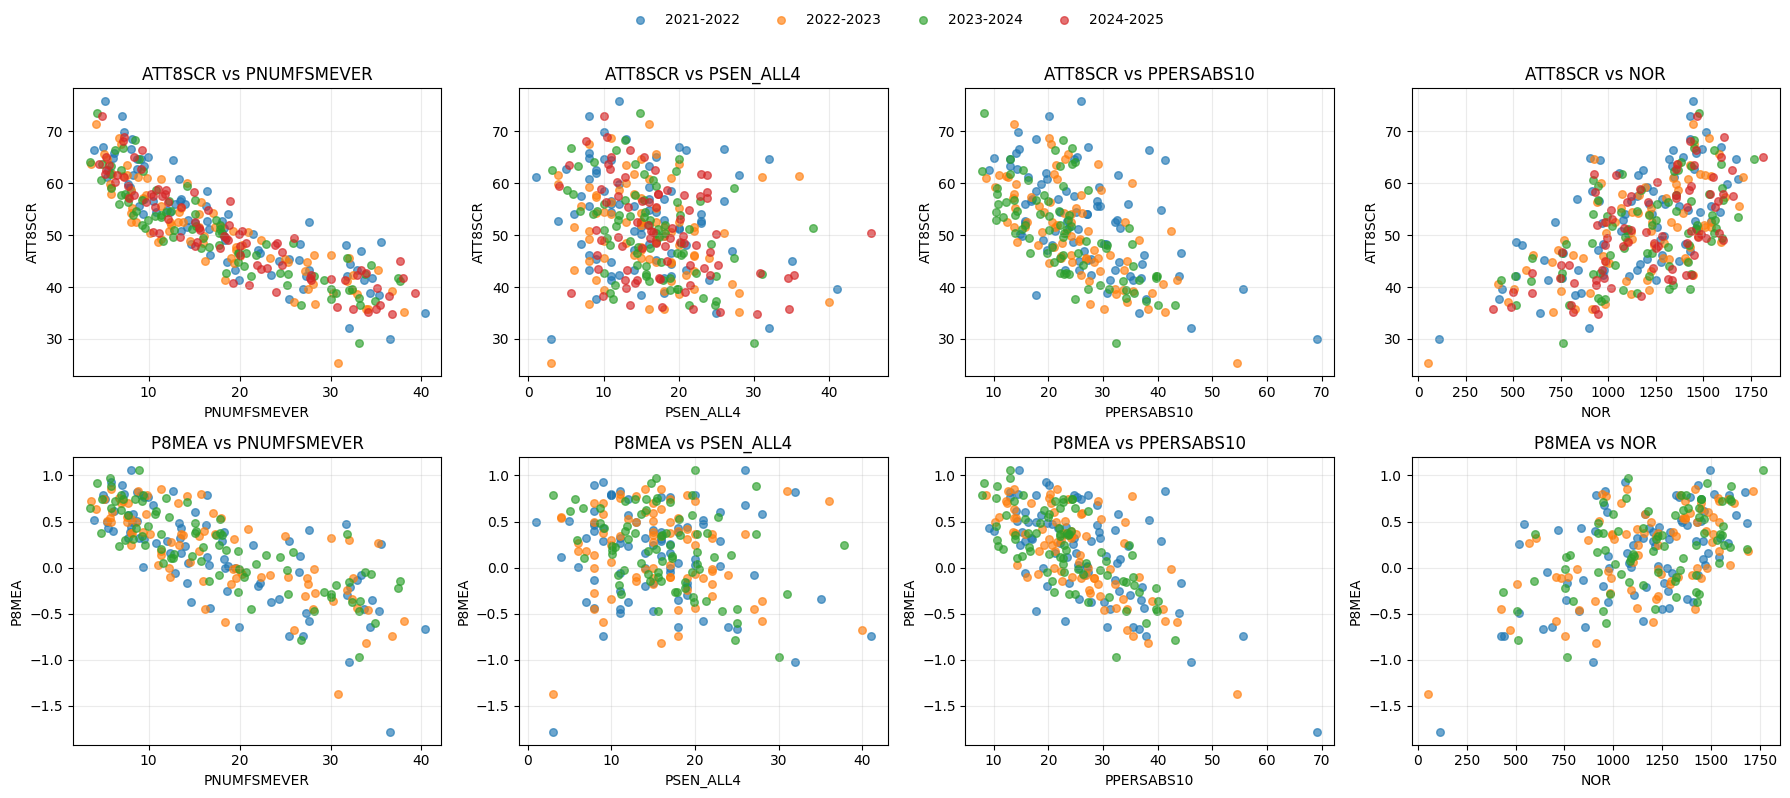

In [ ]:
state_funded_panel = panel.copy()

def scatter_by_year(x: str, y: str, ax: plt.Axes) -> None:
    valid = state_funded_panel.dropna(subset=[x, y])
    for year, group in valid.groupby("academic_year"):
        ax.scatter(group[x], group[y], label=year, alpha=0.65, s=30)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{y} vs {x}")
    ax.grid(alpha=0.25)


scatter_pairs = [
    ("PNUMFSMEVER", "ATT8SCR"),
    ("PSEN_ALL4", "ATT8SCR"),
    ("PPERSABS10", "ATT8SCR"),
    ("NOR", "ATT8SCR"),
    ("PNUMFSMEVER", "P8MEA"),
    ("PSEN_ALL4", "P8MEA"),
    ("PPERSABS10", "P8MEA"),
    ("NOR", "P8MEA"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for axis, (x, y) in zip(axes.ravel(), scatter_pairs):
    scatter_by_year(x, y, axis)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(YEARS), frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.94])

* Across 2021/22–2024/25, secondary school attainment and progress outcomes in Hertfordshire show strong relationships with deprivation, attendance, and school size, while SEND prevalence shows a weaker and more dispersed association.
* Socioeconomic disadvantage remains strongly associated with lower GCSE attainment outcomes and continue to influence pupil progress even after accounting for prior attainment.
* Persistent absence is also strongly associated with lower Attainment 8 outcomes and lower Progress 8 scores.
* Larger schools tend to have higher Attainment 8 scores and higher Progress 8 scores. However, this relationship likely reflects confounding factors, school selectivity, demographic composition, and affluent catchment effects, rather than a direct effect of school size itself.

In [ ]:
fig, axis = plt.subplots(figsize=(7, 5))
scatter_by_year("PNORG", "ATT8SCR", axis)

handles, labels = axis.get_legend_handles_labels()
axis.legend(handles, labels, title="Academic year", frameon=False)
plt.tight_layout()

In [ ]:
TARGETS = ["ATT8SCR", "P8MEA"]
NUMERIC_CONTEXT_COLUMNS = ["PNUMFSMEVER", "PERCTOT", "PPERSABS10", "PSEN_ALL4", "NOR", "PNORG"]

NUMERIC_FEATURES = panel[TARGETS + NUMERIC_CONTEXT_COLUMNS].apply(pd.to_numeric, errors="coerce")
feature_correlations = NUMERIC_FEATURES.corr()

fig, axis = plt.subplots(figsize=(7, 6))
heatmap = axis.imshow(feature_correlations, cmap="coolwarm", vmin=-1, vmax=1)
axis.set_xticks(range(len(feature_correlations.columns)))
axis.set_xticklabels(feature_correlations.columns, rotation=45, ha="right")
axis.set_yticks(range(len(feature_correlations.index)))
axis.set_yticklabels(feature_correlations.index)

for row in range(len(feature_correlations.index)):
    for col in range(len(feature_correlations.columns)):
        value = feature_correlations.iloc[row, col]
        axis.text(col, row, f"{value:.2f}", ha="center", va="center", color="black", fontsize=9)

axis.set_title("Context Feature Correlations")
fig.colorbar(heatmap, ax=axis, fraction=0.046, pad=0.04)
plt.tight_layout()

display(feature_correlations.round(3))
display(
    feature_correlations.loc[NUMERIC_CONTEXT_COLUMNS, TARGETS]
    .sort_values("ATT8SCR", key=lambda values: values.abs(), ascending=False)
    .round(3)
    .rename(columns={target: f"correlation_with_{target}" for target in TARGETS})
)

## Multiple Regression: Predicting Attainment and Progress

This section predicts `ATT8SCR` and `P8MEA` using selected context variables for state-funded secondary schools only. It is descriptive and predictive, not causal.

`PPERSABS10` is omitted because it is strongly related to `PERCTOT`, while `PNORG` is omitted because the correlation check shows a weak relationship with attainment. The numeric regression features are therefore `PNUMFSMEVER`, `PERCTOT`, `PSEN_ALL4`, and `NOR`. `PERCTOT` and `P8MEA` are not available for `2024-2025`, so the models use years with the required target and attendance data only.

In [ ]:
REGRESSION_TARGETS = ["ATT8SCR", "P8MEA"]
REGRESSION_NUMERIC_FEATURES = ["PNUMFSMEVER", "PERCTOT", "PSEN_ALL4", "NOR"]
REGRESSION_CATEGORICAL_FEATURES = ["academic_year", "EGENDER", "ADMPOL"]

regression_row_counts = []
regression_summaries = []
coefficient_tables = []
prediction_tables = []

for target in REGRESSION_TARGETS:
    regression_columns = [target] + REGRESSION_NUMERIC_FEATURES + REGRESSION_CATEGORICAL_FEATURES + ["URN", "SCHNAME"]
    regression_data = panel[regression_columns].copy()
    regression_data[REGRESSION_CATEGORICAL_FEATURES] = regression_data[REGRESSION_CATEGORICAL_FEATURES].fillna("Missing")
    regression_data = regression_data.dropna(subset=[target] + REGRESSION_NUMERIC_FEATURES).copy()

    X_numeric_raw = regression_data[REGRESSION_NUMERIC_FEATURES].astype(float)
    feature_means = X_numeric_raw.mean()
    feature_stds = X_numeric_raw.std(ddof=0).replace(0, 1)
    X_numeric = (X_numeric_raw - feature_means) / feature_stds
    X_categorical = pd.get_dummies(regression_data[REGRESSION_CATEGORICAL_FEATURES], drop_first=True, dtype=float)
    X = pd.concat([X_numeric, X_categorical], axis=1)
    X.insert(0, "Intercept", 1.0)
    y = regression_data[target].astype(float)

    beta, residuals, rank, singular_values = np.linalg.lstsq(X.to_numpy(dtype=float), y.to_numpy(dtype=float), rcond=None)
    predicted = X.to_numpy(dtype=float) @ beta
    errors = y.to_numpy(dtype=float) - predicted

    n_obs = len(y)
    n_features = X.shape[1] - 1
    sse = float(np.sum(errors**2))
    sst = float(np.sum((y - y.mean()) ** 2))
    r2 = 1 - sse / sst
    adj_r2 = 1 - (1 - r2) * (n_obs - 1) / (n_obs - n_features - 1)
    rmse = float(np.sqrt(np.mean(errors**2)))
    mae = float(np.mean(np.abs(errors)))

    regression_row_counts.append(regression_data.groupby("academic_year").size().rename(target))
    regression_summaries.append(
        {
            "target": target,
            "observations": n_obs,
            "features": n_features,
            "rank": rank,
            "r2": r2,
            "adjusted_r2": adj_r2,
            "rmse": rmse,
            "mae": mae,
        }
    )

    coefficient_tables.append(
        pd.DataFrame({"target": target, "feature": X.columns, "coefficient": beta})
        .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
        .sort_values("abs_coefficient", ascending=False)
        .drop(columns="abs_coefficient")
    )

    prediction_table = regression_data[["academic_year", "URN", "SCHNAME", target]].rename(columns={target: "actual"})
    prediction_table.insert(0, "target", target)
    prediction_table["predicted"] = predicted
    prediction_table["residual"] = prediction_table["actual"] - prediction_table["predicted"]
    prediction_tables.append(prediction_table)

regression_row_counts = pd.concat(regression_row_counts, axis=1).fillna(0).astype(int)
regression_summary = pd.DataFrame(regression_summaries)
coefficient_table = pd.concat(coefficient_tables, ignore_index=True)
prediction_results = pd.concat(prediction_tables, ignore_index=True)

display(regression_row_counts)
display(regression_summary.round(3))
display(coefficient_table.round(3))
display(
    prediction_results.assign(abs_residual=lambda frame: frame["residual"].abs())
    .sort_values(["target", "abs_residual"], ascending=[True, False])
    .groupby("target")
    .head(15)
    .drop(columns="abs_residual")
    .round(2)
)

fig, axes = plt.subplots(1, len(REGRESSION_TARGETS), figsize=(6.5 * len(REGRESSION_TARGETS), 5.5))
for axis, target in zip(np.atleast_1d(axes), REGRESSION_TARGETS):
    target_predictions = prediction_results[prediction_results["target"].eq(target)]
    axis.scatter(target_predictions["actual"], target_predictions["predicted"], alpha=0.7)
    line_min = min(target_predictions["actual"].min(), target_predictions["predicted"].min())
    line_max = max(target_predictions["actual"].max(), target_predictions["predicted"].max())
    axis.plot([line_min, line_max], [line_min, line_max], color="black", linewidth=1, alpha=0.6)
    axis.set_title(f"Actual vs Predicted {target}")
    axis.set_xlabel(f"Actual {target}")
    axis.set_ylabel(f"Predicted {target}")
    axis.grid(alpha=0.25)
plt.tight_layout()

## Grouped Summaries

In [ ]:
def grouped_summary(group_col: str) -> pd.DataFrame:
    return (
        panel.groupby(["academic_year", group_col], dropna=False)
        .agg(
            schools=("URN", "count"),
            mean_p8=("P8MEA", "mean"),
            mean_att8=("ATT8SCR", "mean"),
            mean_grade5=("PTL2BASICS_95", "mean"),
            mean_fsm=("PNUMFSMEVER", "mean"),
            mean_persistent_absence=("PPERSABS10", "mean"),
            mean_send=("PSEN_ALL4", "mean"),
            mean_nor=("NOR", "mean"),
            mean_norg=("NORG", "mean"),
            mean_norb=("NORB", "mean"),
            mean_pnorg=("PNORG", "mean"),
            mean_pnorb=("PNORB", "mean"),
        )
        .reset_index()
        .sort_values(["academic_year", "schools"], ascending=[True, False])
    )


for group_column in ["SCHOOLTYPE", "ADMPOL", "EGENDER"]:
    print(f"\n{group_column}")
    display(grouped_summary(group_column).round(2))

## Ranked School Tables

In [ ]:
ranking_columns = [
    "academic_year",
    "URN",
    "SCHNAME",
    "SCHOOLTYPE",
    "ADMPOL",
    "EGENDER",
    "P8MEA",
    "ATT8SCR",
    "PTL2BASICS_95",
    "PNUMFSMEVER",
    "PPERSABS10",
    "PSEN_ALL4",
    "NOR",
    "NORG",
    "NORB",
    "PNORG",
    "PNORB",
]

high_deprivation = (
    panel.dropna(subset=["PNUMFSMEVER"])
    .sort_values(["academic_year", "PNUMFSMEVER", "ATT8SCR"], ascending=[True, False, False])
    .groupby("academic_year")
    .head(10)[ranking_columns]
)

highest_attainment = (
    panel.dropna(subset=["ATT8SCR"])
    .sort_values(["academic_year", "ATT8SCR"], ascending=[True, False])
    .groupby("academic_year")
    .head(10)[ranking_columns]
)

display(high_deprivation.round(2))
display(highest_attainment.round(2))

## Policy Findings Evidence

The tables below collect the main evidence used for the final policy summary.

In [ ]:
policy_outcome_summary = (
    panel.groupby("academic_year")
    .agg(
        schools=("URN", "count"),
        mean_att8=("ATT8SCR", "mean"),
        mean_grade5=("PTL2BASICS_95", "mean"),
        mean_p8=("P8MEA", "mean"),
        mean_fsm6=("PNUMFSMEVER", "mean"),
        mean_persistent_absence=("PPERSABS10", "mean"),
        mean_send=("PSEN_ALL4", "mean"),
        mean_nor=("NOR", "mean"),
    )
    .round(2)
)

policy_correlation_summary = (
    panel.loc[panel["academic_year"].ne("2024-2025"), REGRESSION_TARGETS + ["PNUMFSMEVER", "PERCTOT", "PPERSABS10", "PSEN_ALL4", "NOR", "PNORG"]]
    .corr(numeric_only=True)
    .loc[["PNUMFSMEVER", "PERCTOT", "PPERSABS10", "PSEN_ALL4", "NOR", "PNORG"], REGRESSION_TARGETS]
    .rename(columns={target: f"correlation_with_{target}" for target in REGRESSION_TARGETS})
    .round(3)
)

policy_regression_coefficients = (
    coefficient_table[coefficient_table["feature"].isin(REGRESSION_NUMERIC_FEATURES)]
    .pivot(index="feature", columns="target", values="coefficient")
    .round(3)
)

display(policy_outcome_summary)
display(policy_correlation_summary)
display(policy_regression_coefficients)


## Policy Summary

This notebook now analyses **state-funded secondary schools only**, so the findings are about the local mainstream secondary accountability system rather than independent or special-school provision.

**Main findings**

- Attainment is broadly flat after a post-2021-2022 drop. Mean `ATT8SCR` falls from about **52.9** in `2021-2022` to about **50.6-50.8** from `2022-2023` onward. The grade 5+ English/maths measure also falls from about **56.3%** to about **52.8-53.8%**.
- Progress 8 is positive and slightly improving where populated: mean `P8MEA` rises from about **0.15** in `2021-2022` to **0.21** in `2023-2024`. `2024-2025` should not be used for Progress 8 conclusions because the selected Progress 8 columns are not populated.
- Deprivation is the strongest policy signal. `PNUMFSMEVER` has a strong negative association with `ATT8SCR` in the available years, and it is the largest contextual coefficient in the multiple regression. This supports prioritising disadvantaged-pupil attainment and school-level deprivation as the main equity lens.
- Attendance is also policy-relevant. Persistent absence improves from about **26.5%** in `2021-2022` to **23.4%** in `2023-2024`, but absence remains strongly negatively associated with `ATT8SCR`. `2024-2025` has no absence file, so attendance findings stop at `2023-2024`.
- SEND need is rising: mean `PSEN_ALL4` increases from about **15.5%** to **17.6%** across the panel. Its simple relationship with attainment is weaker than deprivation and attendance, and the regression suggests much of the SEND signal overlaps with other context variables.
- Smaller `ADMPOL == NR` schools have lower average attainment and higher deprivation/absence in these data, but there are only about six such schools per year. Treat this as a flag for follow-up rather than a standalone policy conclusion.

**Policy implications**

- Focus intervention analysis on high-`PNUMFSMEVER` schools first, then inspect attendance as a likely operational lever.
- Use state-funded secondary schools as the benchmark group for DfE accountability metrics; independent-school accountability values are not comparable and have been excluded from the panel.
- Report `2024-2025` attainment outcomes, but keep Progress 8 and attendance trend claims limited to years where those fields are populated.
- Treat the regression as descriptive evidence for prioritisation, not causal proof. The model explains a large share of variation, but the predictors are correlated and the school-year panel is small.
